# RNN

In [1]:
from collections import Counter
import numpy as np

seq = "abcdefghijklmnopqrstuvwxyz abcdefghijklmnopqrstuvwxyz abcdefghijklmnopqrstuvwxyz"

c = Counter(seq)

cl = list(c.keys())

vocab = {}
inv_vocab = {}

for i, k in enumerate(cl):
    vocab[k] = i
    inv_vocab[i] = k

vocab_size = len(vocab)

lookup = np.eye(vocab_size)

seq_encoded = []
for ch in seq:
    seq_encoded.append(lookup[vocab[ch]])

x = np.expand_dims(np.array(seq_encoded[:-1]), axis=0)
y = np.expand_dims(np.array(seq_encoded[1:]), axis=0)

print(f"Unique tokens: {vocab_size}")
print(f"Total tokens: {len(seq_encoded)}")


Unique tokens: 27
Total tokens: 80


In [2]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import RNN, LSTM
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        LSTM(in_dim=vocab_size, hidden_dim=32, out_dim=vocab_size),
        # Sigmoid(),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 0


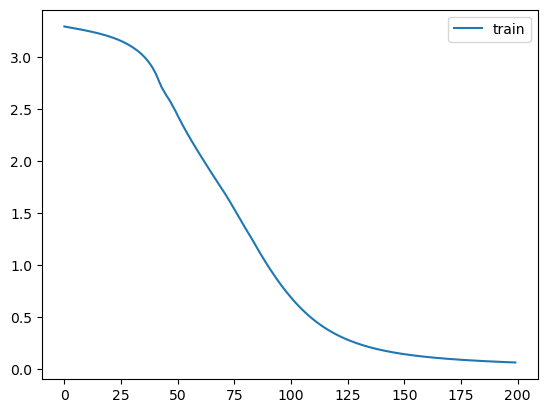

In [17]:
import matplotlib.pyplot as plt
from NNLibrary.Layers.loss import CrossEntropy, SoftmaxCE
from NNLibrary.optimizers import Adam, GradientDescent

epochs = 200
lr = 0.001

loss_fn = SoftmaxCE()
optimizer = Adam(lr, beta=0.9, gamma=0.999)
# optimizr = GradientDescent(lr=lr)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    network.train()

    metrics["epochs"].append(epoch)

    out = network.forward(x)
    loss = loss_fn.forward(out, y)

    network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    
    metrics["train"]["loss"].append(loss)
    metrics["train"]["epoch"].append(epoch)


plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
# plt.plot(metrics["val"]["epoch"], metrics["val"]["loss"], label="val")
plt.legend()
plt.show()

In [3]:
from NNLibrary.Layers.activations import Softmax

# np.random.seed(11)

softmax = Softmax(T=0.1)

seed = "a"

context = [lookup[vocab[ch]] for ch in seed] # List of one-hot

out_seq = seed
out_len = 64

for _ in range(out_len):
    x_in = np.expand_dims(np.array(context), axis=0)
    logits = network.forward(x_in)
    pred = softmax.forward(logits)

    next_id = np.random.choice(vocab_size, p=pred[0, -1])
    next_ch = inv_vocab[next_id]

    out_seq += next_ch
    context.append(lookup[next_id])

print(out_seq)

abifnmmimonofmottoqkooftmoolmodomhtlq jywwpnfolbtofmfoljlbjlpmoim
